<a href="https://colab.research.google.com/github/harshinisathya09-star/projects-/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

In [6]:
import pandas as pd
df = pd.read_csv("/content/customer_churn_1M.csv")

In [7]:
df.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1.0,1.0,9.0,0.0,0.0,0.0,109.63,16.0,NaN,0.0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0.0,1.0,7.0,0.0,3.0,1.0,63.25,134.0,585.0,0.0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1.0,0.0,6.0,1.0,1.0,0.0,47.77,11.0,632.0,0.0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0.0,1.0,5.0,2.0,2.0,1.0,50.82,6.0,569.0,0.0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0.0,1.0,8.0,1.0,1.0,0.0,16.74,18.0,657.0,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24592 entries, 0 to 24591
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  24592 non-null  object 
 1   signup_date                  24592 non-null  object 
 2   age                          24592 non-null  int64  
 3   gender                       24592 non-null  object 
 4   annual_income                23869 non-null  float64
 5   education                    24592 non-null  object 
 6   marital_status               24592 non-null  object 
 7   dependents                   24592 non-null  int64  
 8   tenure                       24592 non-null  int64  
 9   contract                     24592 non-null  object 
 10  payment_method               24592 non-null  object 
 11  paperless_billing            24592 non-null  object 
 12  senior_citizen               24592 non-null  int64  
 13  monthlycharges  

In [9]:
df.describe()

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
count,24592.000000,23869.000000,24592.000000,24592.000000,24592.000000,24592.000000,24591.000000,24591.000000,24591.000000,24591.000000,...,24591.000000,24591.000000,24124.000000,23826.000000,24591.00000,24591.000000,23354.000000,24591.000000,23578.000000,24591.000000
mean,44.798959,58834.605471,0.802334,22.567664,0.199862,86.457290,1853.760950,2.563174,0.772681,0.850067,...,0.601521,0.551137,6.124482,0.705196,1.75792,0.401529,39.183913,44.610508,679.280431,0.101175
std,14.464331,37119.917795,0.891178,20.126823,0.399904,26.665691,1815.819515,1.407434,0.419109,0.357013,...,0.489595,0.497388,2.334353,0.839009,1.49125,0.632369,43.461567,45.141763,87.588743,0.301567
min,18.000000,20000.000000,0.000000,1.000000,0.000000,20.000000,20.750000,1.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,300.000000,0.000000
25%,34.000000,32555.330000,0.000000,7.000000,0.000000,70.807500,504.595000,1.000000,1.000000,1.000000,...,0.000000,0.000000,4.000000,0.000000,1.00000,0.000000,12.742500,13.000000,620.000000,0.000000
50%,45.000000,48891.570000,1.000000,16.000000,0.000000,85.560000,1265.090000,2.000000,1.000000,1.000000,...,1.000000,1.000000,7.000000,1.000000,1.00000,0.000000,27.960000,31.000000,680.000000,0.000000
75%,55.000000,73661.100000,1.000000,33.000000,0.000000,100.740000,2622.195000,3.000000,1.000000,1.000000,...,1.000000,1.000000,8.000000,1.000000,3.00000,1.000000,51.777500,62.000000,741.000000,0.000000
max,90.000000,250000.000000,5.000000,72.000000,1.000000,853.190579,12508.890000,6.000000,1.000000,1.000000,...,1.000000,1.000000,9.000000,6.000000,12.00000,5.000000,541.967398,365.000000,850.000000,1.000000


In [10]:
df.shape

(24592, 32)

In [11]:
df.isnull().sum()

,0
customer_id,0
signup_date,0
age,0
gender,0
annual_income,723
education,0
marital_status,0
dependents,0
tenure,0
contract,0


In [12]:
df.drop("customer_id",axis=1, inplace=True)

In [13]:
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")

In [14]:
df["totalcharges"].fillna(df["totalcharges"].median(), inplace=True)

/tmp/ipykernel_966/122272169.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["totalcharges"].fillna(df["totalcharges"].median(), inplace=True)


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [36]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [37]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [38]:
print(df.isnull().sum())

signup_date                    0
age                            0
gender                         0
annual_income                  0
education                      0
marital_status                 0
dependents                     0
tenure                         0
contract                       0
payment_method                 0
paperless_billing              0
senior_citizen                 0
monthlycharges                 0
totalcharges                   0
num_services                   0
has_phone_service              0
has_internet_service           0
has_online_security            0
has_online_backup              0
has_device_protection          0
has_tech_support               0
has_streaming_tv               0
has_streaming_movies           0
customer_satisfaction          0
num_complaints                 0
num_service_calls              0
late_payments                  0
avg_monthly_gb                 0
days_since_last_interaction    0
credit_score                   0
churn     

In [17]:
df.corr()

,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
signup_date,1.000000,-0.002318,-0.002018,0.000640,0.014586,-0.003120,0.009416,-0.012656,-0.012673,-0.004721,...,0.004696,-0.007500,0.004173,0.001799,-0.000968,-0.002958,-0.006338,-0.002868,0.007321,0.003012
age,-0.002318,1.000000,-0.000289,0.015581,0.000764,0.006299,-0.002550,-0.005829,-0.000028,0.004270,...,-0.011312,-0.002348,-0.001138,0.011824,0.001767,-0.002734,-0.003021,-0.005016,-0.004916,-0.005231
gender,-0.002018,-0.000289,1.000000,0.003292,0.003087,-0.006322,0.002390,-0.006570,0.005724,-0.000509,...,0.012482,-0.010325,-0.001952,-0.003809,-0.000608,-0.006377,-0.007130,-0.005626,0.008162,0.005691
annual_income,0.000640,0.015581,0.003292,1.000000,0.001641,0.003588,-0.003243,0.004204,0.002375,-0.004300,...,-0.002483,-0.003846,0.001626,0.000718,0.007412,0.000404,-0.000706,0.000248,-0.007172,-0.003071
education,0.014586,0.000764,0.003087,0.001641,1.000000,-0.000174,0.013071,0.009157,0.005272,0.010172,...,0.011947,0.002098,-0.006413,-0.008527,0.005999,0.001871,0.010726,-0.003299,0.008944,-0.001703
marital_status,-0.003120,0.006299,-0.006322,0.003588,-0.000174,1.000000,0.009535,-0.005269,0.001100,-0.003637,...,-0.000198,0.000730,-0.000072,-0.003700,-0.008368,0.001634,-0.010496,0.007829,0.000067,-0.009271
dependents,0.009416,-0.002550,0.002390,-0.003243,0.013071,0.009535,1.000000,-0.012079,0.013441,0.000628,...,0.007306,0.008489,-0.005904,-0.005566,-0.006136,0.003062,-0.003522,0.004047,0.009016,-0.000346
tenure,-0.012656,-0.005829,-0.006570,0.004204,0.009157,-0.005269,-0.012079,1.000000,-0.011533,-0.010291,...,-0.000399,-0.000244,0.006442,-0.001702,-0.001360,-0.008691,0.007507,-0.006267,0.005819,-0.016045
contract,-0.012673,-0.000028,0.005724,0.002375,0.005272,0.001100,0.013441,-0.011533,1.000000,-0.004558,...,0.003019,-0.002098,-0.001124,0.005282,-0.003871,-0.008564,-0.007053,-0.000021,-0.001645,-0.129018
payment_method,-0.004721,0.004270,-0.000509,-0.004300,0.010172,-0.003637,0.000628,-0.010291,-0.004558,1.000000,...,-0.005355,0.004605,-0.007786,0.000574,0.002202,-0.002452,-0.001118,-0.009735,-0.006941,-0.000324


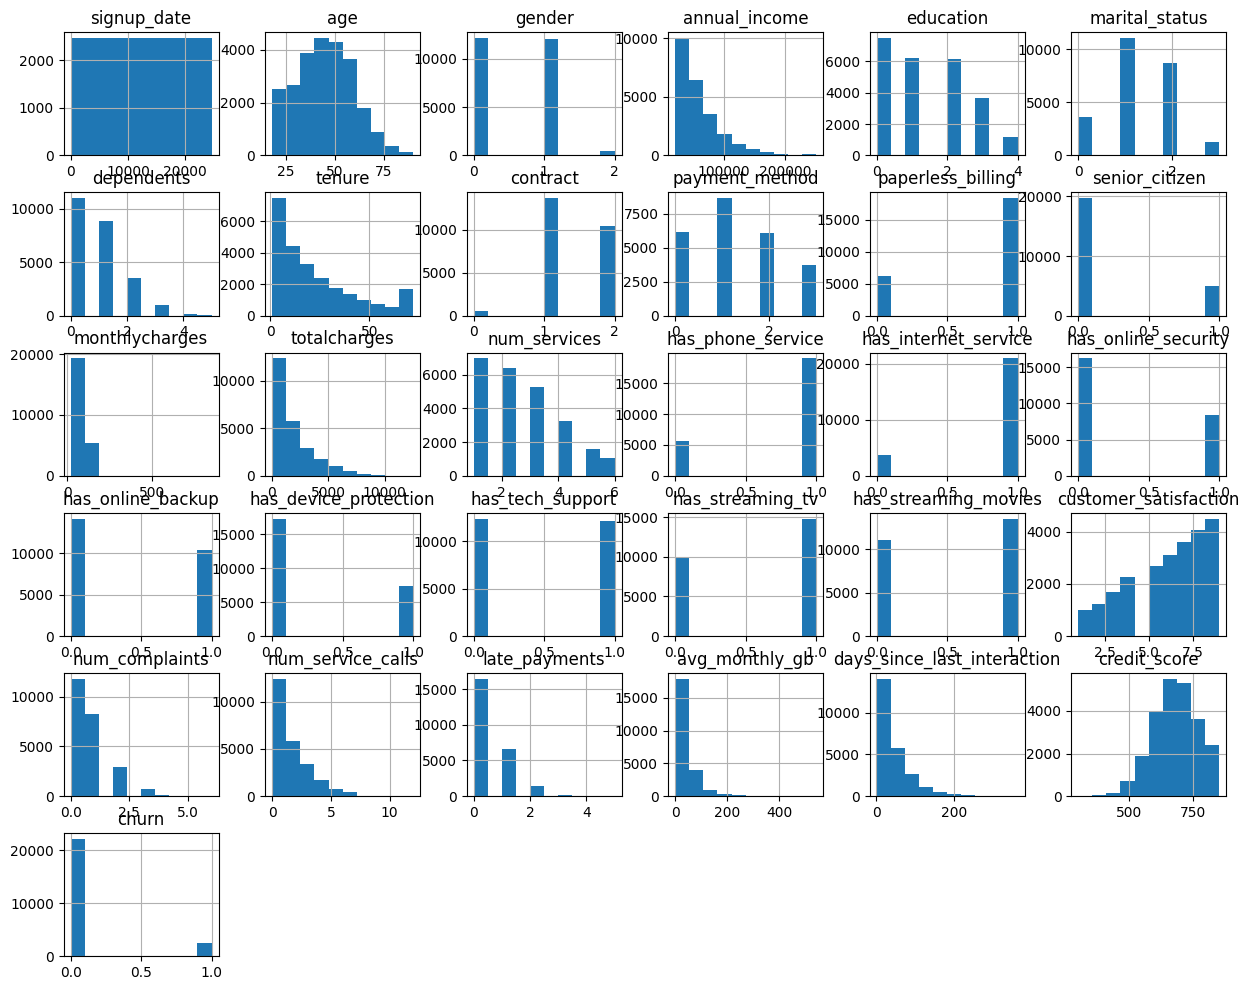

In [18]:
import matplotlib.pyplot as plt
df.hist(figsize=(15,12))
plt.show()

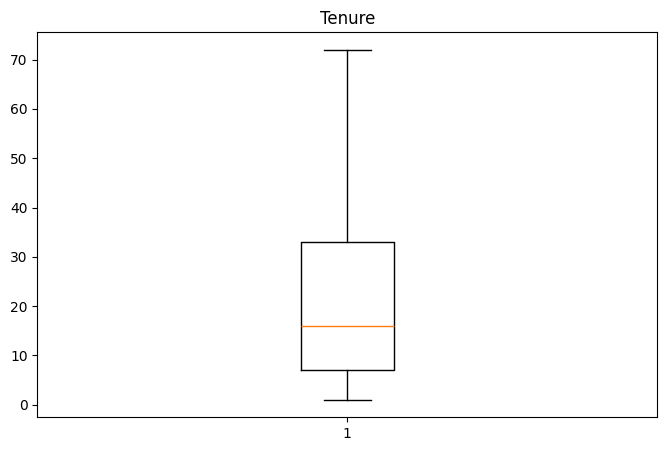

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df["tenure"])
plt.title("Tenure")
plt.show()

In [20]:
print(df.columns)

Index(['signup_date', 'age', 'gender', 'annual_income', 'education',
       'marital_status', 'dependents', 'tenure', 'contract', 'payment_method',
       'paperless_billing', 'senior_citizen', 'monthlycharges', 'totalcharges',
       'num_services', 'has_phone_service', 'has_internet_service',
       'has_online_security', 'has_online_backup', 'has_device_protection',
       'has_tech_support', 'has_streaming_tv', 'has_streaming_movies',
       'customer_satisfaction', 'num_complaints', 'num_service_calls',
       'late_payments', 'avg_monthly_gb', 'days_since_last_interaction',
       'credit_score', 'churn'],
      dtype='object')


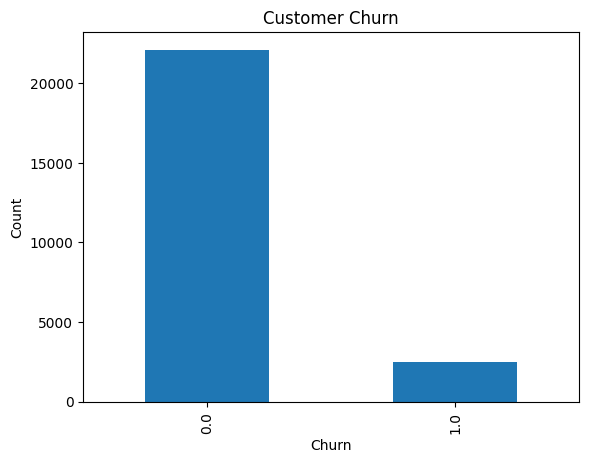

In [21]:
df["churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [22]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [23]:
print(df["churn"].unique())

[ 0.  1. nan]


In [24]:
df["charges_per_service"] = df["totalcharges"] / (df["num_services"] + 1)

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[1,2,3,4]
)

df.head()

,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,...,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn,charges_per_service,tenure_group
0,9484,43,0,55085.25,1,1,1,2,2,2,...,9.0,0.0,0.0,0.0,109.63,16.0,NaN,0.0,72.195000,1
1,4947,18,1,60786.11,3,1,1,22,1,0,...,7.0,0.0,3.0,1.0,63.25,134.0,585.0,0.0,534.073333,2
2,13159,38,0,73184.32,2,3,0,3,2,1,...,6.0,1.0,1.0,0.0,47.77,11.0,632.0,0.0,65.762000,1
3,7136,44,1,40923.78,2,1,1,6,2,0,...,5.0,2.0,2.0,1.0,50.82,6.0,569.0,0.0,160.862500,1
4,9422,45,0,36400.94,0,2,0,9,2,1,...,8.0,1.0,1.0,0.0,16.74,18.0,657.0,0.0,162.197500,1


In [25]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [26]:
print(df["churn"].unique())

[ 0.  1. nan]


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
X.dtypes

,0
signup_date,int64
age,int64
gender,int64
annual_income,float64
education,int64
marital_status,int64
dependents,int64
tenure,int64
contract,int64
payment_method,int64


In [43]:
import numpy as np

print(np.isinf(X_train).sum())
print(np.isinf(X_test).sum())

0
0


In [44]:
print(X.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


In [45]:
print(X.dtypes)

signup_date                       int64
age                               int64
gender                            int64
annual_income                   float64
education                         int64
marital_status                    int64
dependents                        int64
tenure                            int64
contract                          int64
payment_method                    int64
paperless_billing                 int64
senior_citizen                    int64
monthlycharges                  float64
totalcharges                    float64
num_services                    float64
has_phone_service               float64
has_internet_service            float64
has_online_security             float64
has_online_backup               float64
has_device_protection           float64
has_tech_support                float64
has_streaming_tv                float64
has_streaming_movies            float64
customer_satisfaction           float64
num_complaints                  float64


In [47]:
print(pd.DataFrame(X_train).isnull().sum().sum())

3378


In [53]:
df.drop(["customer_id", "signup_date"], axis=1, inplace=True, errors="ignore")

In [54]:
df.drop(["customer_id", "signup_date"], axis=1, inplace=True, errors="ignore")

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [56]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [60]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [61]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [64]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print("SVM trained successfully")

SVM trained successfully


In [65]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

def evaluate(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred))
    print("Recall :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix")
    print(confusion_matrix(y_true, y_pred))

In [66]:
print("KNN Results")

evaluate(y_test, pred_knn)

KNN Results
Accuracy : 0.8936775767432404
Precision : 0.20754716981132076
Recall : 0.022357723577235773
F1 Score : 0.04036697247706422
Confusion Matrix
[[4385   42]
 [ 481   11]]


In [67]:
print("Decision Tree Results")

evaluate(y_test, pred_dt)

Decision Tree Results
Accuracy : 0.8115470624110591
Precision : 0.135678391959799
Recall : 0.16463414634146342
F1 Score : 0.1487603305785124
Confusion Matrix
[[3911  516]
 [ 411   81]]


In [68]:
print("Random Forest Results")

evaluate(y_test, pred_rf)

Random Forest Results
Accuracy : 0.8999796706647692
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
Confusion Matrix
[[4427    0]
 [ 492    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
print("SVM Results")

evaluate(y_test, pred_svm)

SVM Results
Accuracy : 0.8999796706647692
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
Confusion Matrix
[[4427    0]
 [ 492    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
comparison = pd.DataFrame({

    "Model": ["KNN", "Decision Tree", "Random Forest", "SVM"],

    "Accuracy": [
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_svm)
    ],

    "Precision": [
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_svm)
    ],

    "Recall": [
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_svm)
    ],

    "F1 Score": [
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_svm)
    ]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.893678   0.207547  0.022358  0.040367
1  Decision Tree  0.811547   0.135678  0.164634  0.148760
2  Random Forest  0.899980   0.000000  0.000000  0.000000
3            SVM  0.899980   0.000000  0.000000  0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [71]:
import joblib
joblib.dump(rf, "customer_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model saved successfully!")

Model saved successfully!


In [74]:
def predict_customer(data):
    data = scaler.transform([data])
    prediction = rf.predict(data)
    if prediction[0] == 1:
        print("Customer Will Churn")
    else:
        print("Customer Will Stay")

The dataset was cleaned, explored, and prepared for machine learning. Different visualization techniques helped understand the data. Four machine learning algorithms were trained and compared, and the best model was saved for deployment using Streamlit. This process helped build an accurate customer churn prediction system.